In [ ]:
# Import necessary libraries
import pandas as pd                 # For reading CSV and data manipulation
import matplotlib.pyplot as plt     # For plotting
from matplotlib.backends.backend_pdf import PdfPages  # To save multiple plots into a single PDF
import os #To access file path

In [ ]:
# ------------------------------
# 1. Read the CSV file
# ------------------------------

# Read the CSV file and parse the 'Date' column as datetime
df = pd.read_csv(os.path.join(os.path.dirname(__file__),"open-meteo-subset.csv"),parse_dates=[0])
df.rename(columns={df.columns[0]: 'time'}, inplace=True)

# Get all numeric columns (all except the first 'time' column)
numeric_columns = df.columns[1:]  

# Print the first few rows to check data
print(df.head())

# Print the data types of each column to confirm parsing
print(df.dtypes)

                 time  temperature_2m (°C)  precipitation (mm)  \
0 2020-01-01 00:00:00                 -2.2                 0.1   
1 2020-01-01 01:00:00                 -2.2                 0.0   
2 2020-01-01 02:00:00                 -2.3                 0.0   
3 2020-01-01 03:00:00                 -2.3                 0.0   
4 2020-01-01 04:00:00                 -2.7                 0.0   

   wind_speed_10m (m/s)  wind_gusts_10m (m/s)  wind_direction_10m (°)  
0                   9.6                  21.3                     284  
1                  10.6                  23.0                     282  
2                  11.0                  23.5                     284  
3                  10.6                  23.3                     284  
4                  10.6                  22.8                     284  
time                      datetime64[ns]
temperature_2m (°C)              float64
precipitation (mm)               float64
wind_speed_10m (m/s)             float64
wind_gu

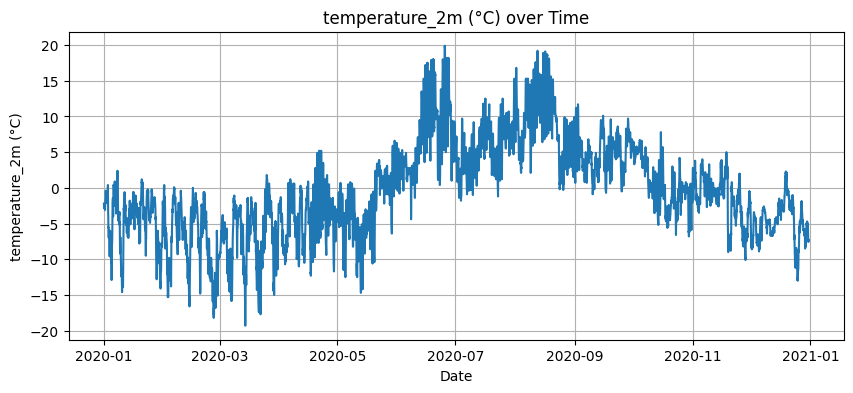

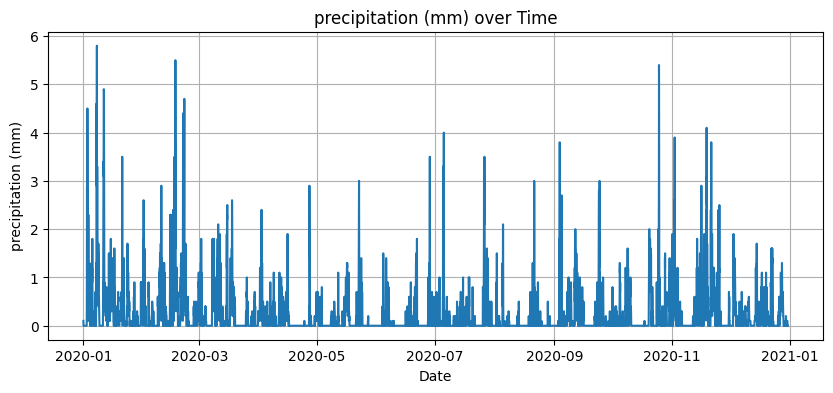

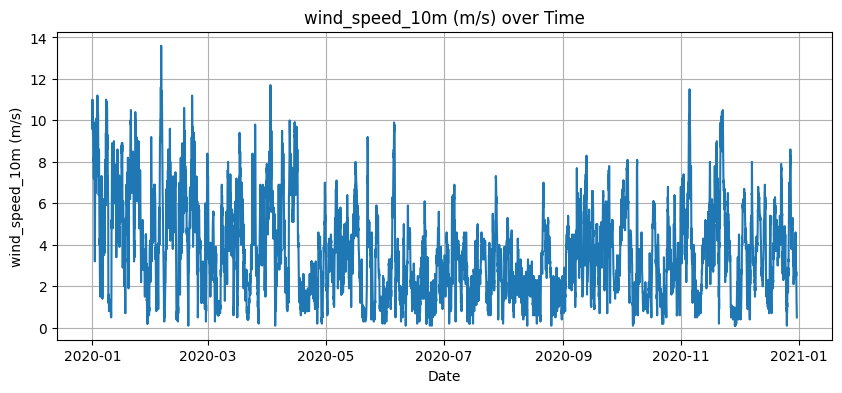

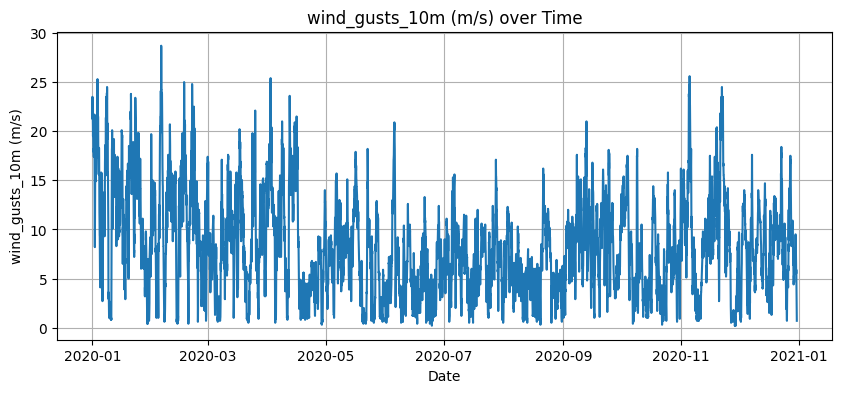

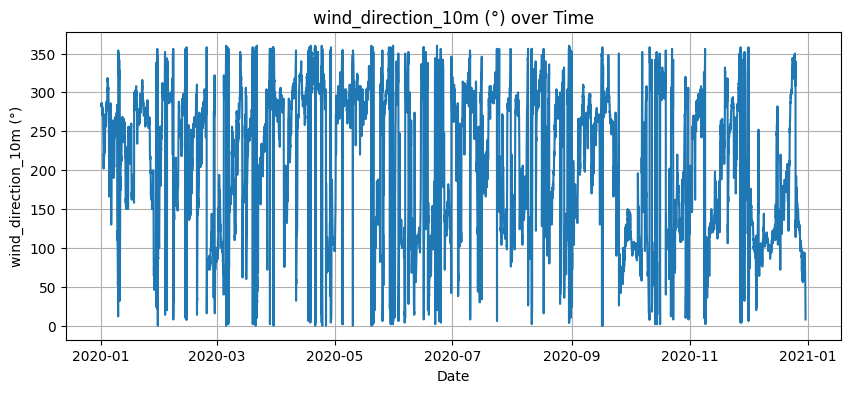

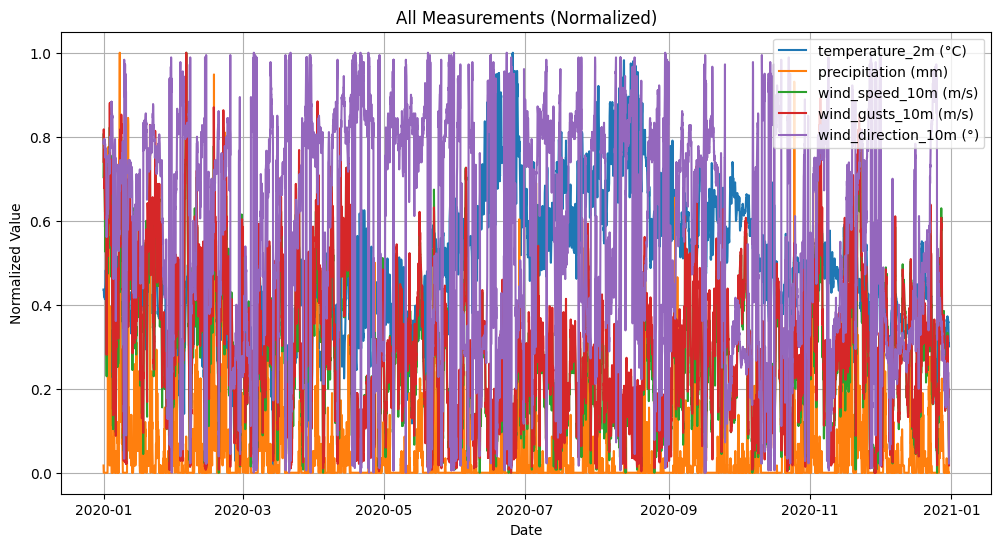

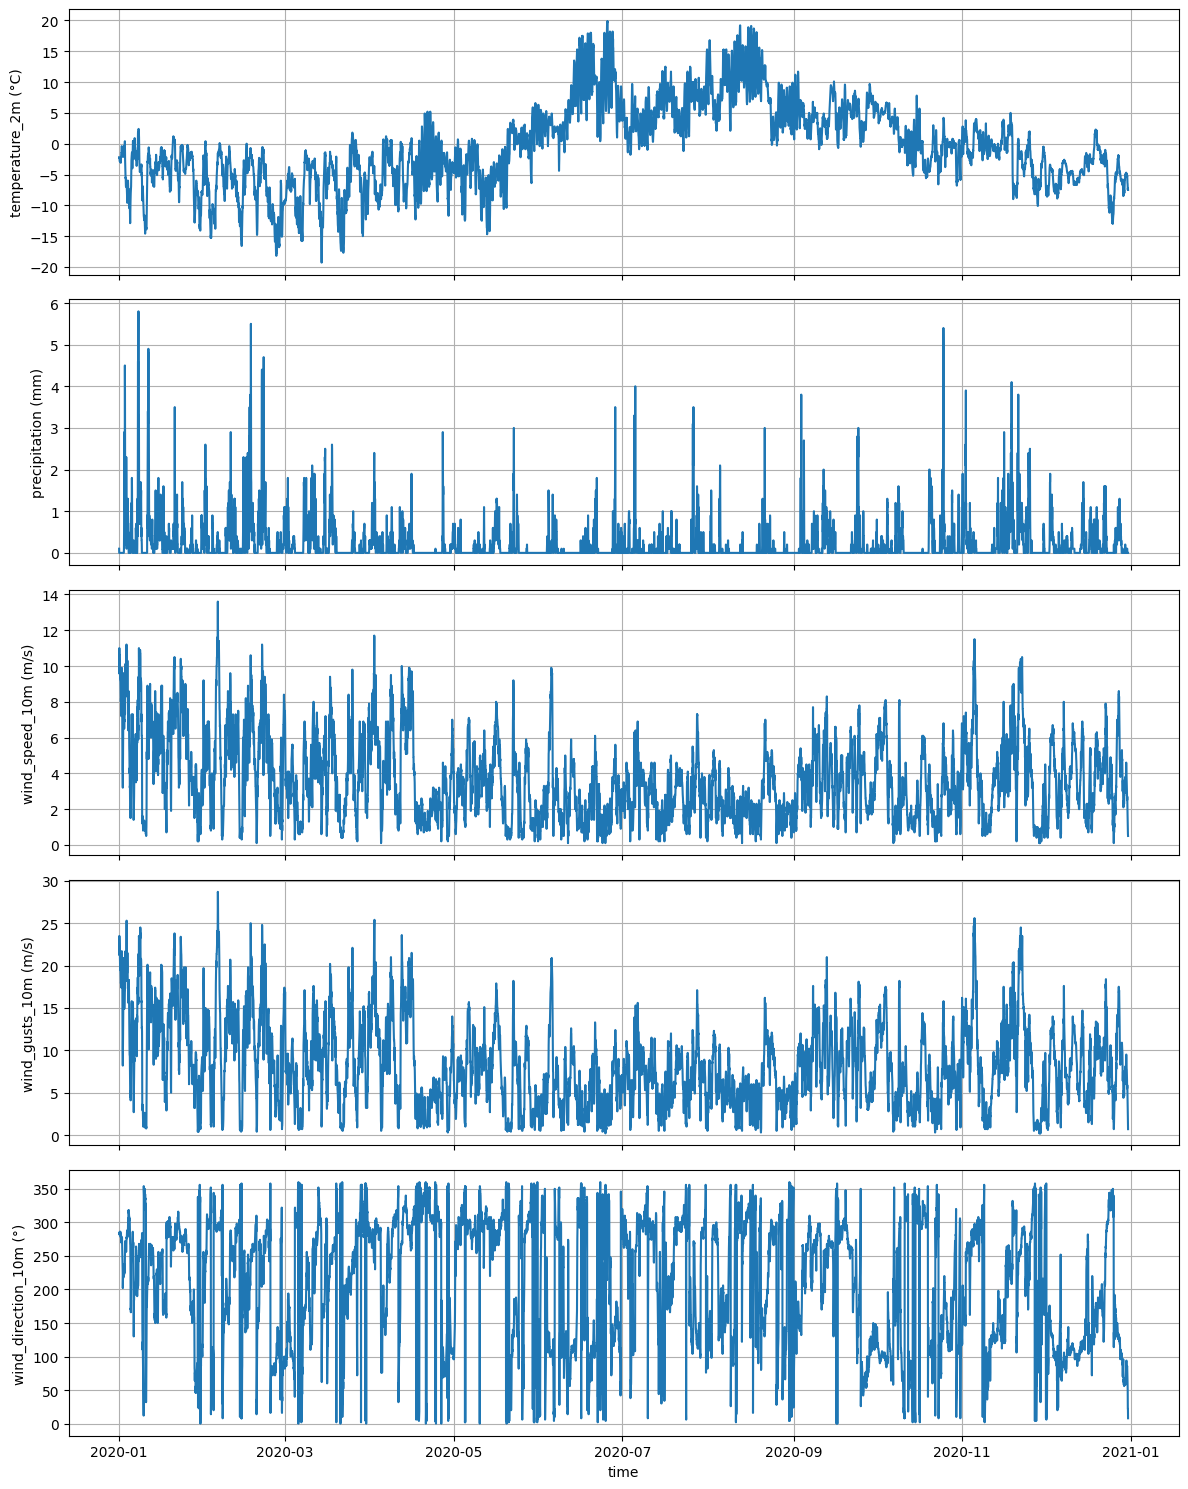

In [ ]:
# 2. Save all plots to a PDF

# Create a PDF file to store all plots
with PdfPages('weather_report.pdf') as pdf:
    
    # 2a. Plot each column separately
    for column in numeric_columns:
        plt.figure(figsize=(10, 4))          # Set figure size
        plt.plot(df['time'], df[column])     # Plot column vs time
        plt.title(f'{column} over Time')     # Title of plot
        plt.xlabel('Date')                   # X-axis label
        plt.ylabel(column)                   # Y-axis label
        plt.grid(True)                       # Show grid for better readability
        pdf.savefig()                        # Save this figure to the PDF
        
    
    # 2b. Plot all columns normalized together
    
    # Make a copy of the dataframe to normalize data
    df_normalized = df.copy()
    
    # Normalize each numeric column to range 0-1
    for column in numeric_columns:
        df_normalized[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
    
    # Create a figure for normalized plot
    plt.figure(figsize=(12, 6))
    
    # Plot each normalized column
    for column in numeric_columns:
        plt.plot(df_normalized['time'], df_normalized[column], label=column)
    
    # Add title, labels, legend, and grid
    plt.title('All Measurements (Normalized)')
    plt.xlabel('Date')
    plt.ylabel('Normalized Value')
    plt.legend()
    plt.grid(True)
    
    pdf.savefig()   # Save normalized plot to PDF
    

    # 2c. Plot all columns in subplots
    
    # Create subplots: one row per variable
    fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(12, 3*len(numeric_columns)), sharex=True)
    
    # Loop through axes and columns
    for ax, column in zip(axes, numeric_columns):
        ax.plot(df['time'], df[column])   # Plot column vs Date
        ax.set_ylabel(column)             # Y-axis label
        ax.grid(True)                     # Add grid
    
    # Set X-axis label only for the bottom subplot
    axes[-1].set_xlabel('time')
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    pdf.savefig()   # Save subplots figure to PDF

The assignment log: 
    At first, there was a struggle to set up GitHub and VS Code. It requires a lot of will power to not give up on trying to connect these two things. The main problem was that i  
accidenty confused VS Code, when decided to switch to a different GitHub account for this assignment. The VSCode didnt quite like it and kept connecting to the old account. The problem was finally resolved somehow via deleting cache (rule of thumb: when in doubt, delete cookies and reboot:)) and setting up everything from the beginning. At this moment i swore to avoid having to set up GitHub again. 
    Once everything was synced, the sailing went smooth. Creating Jupyter Notebook, reading csv and plotting graphs went just fine, without any problems. 

The next step was to set up the Streamlit. Writing the program, was not particularly difficult, thanks to the mighty ChatGPT. Displaying simple version of the app on streamlit, just to check whether it works, went fine also. The problems found me when I tried to connect final app version to the Streamlit. After many hours of rerunning the program, consulting ChatGPT, and contemplating life choices, I was still unable to succesfully deploy the app, as it was failing to import the requirements. In the begining, matplotlib was blamed, since in some cases before this library was not importing succesfully for me. As it appeared at later stage,  the pandas version, which i was trying to import, was not competible with python 13, which newest Streamlit API is using. ChatGPT suggested using runtime txt to force streamlit to use python 10, but it didnt work, so I was forced instead to import older version of pandas. 
The challanges did not end on that though. The task for page 2, using LineChartColumn() to display the first month of the data series, didnt give satisfactory results. The height of the columns was too small, even though i tried adjusting it, it didnt realy help, so I was not satistied with what the table looked like. Therefore, a different solution was tested. And just like that, the app was running and the graphs were shown. 

The app can be accessed here: https://ind320vy-app1.streamlit.app/
The github repository with the code can be found here: https://github.com/Viktoria0720/IND320_VY/tree/main/ASSIGNMENTS/PART1 . hopefully the links leads to the assignment folder, but if no, please go to IND320_VY/ASSIGNMENTS/PART1

Disclaimer: ChatGPT was of great help with writing the code for app and fixing the errors. Dispite using ChatGPT, all the errors, challenges, and problems were experienced firsthand by me. 